<a href="https://colab.research.google.com/github/mythili-97/Python-DA-Capstone-Project/blob/main/Python_DA_Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#data import and Setup:
df=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df['age']=df['age'].astype('Int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   Int64  
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [10]:
df['posted_at']=pd.to_datetime(df['posted_at'],dayfirst=True)

In [ ]:
#Data Cleaning:
#detecting missing values:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
df['age']=df['age'].fillna(df['age'].median())
df['likes']=df['likes'].fillna(df['likes'].median())
df['comments']=df['comments'].fillna(df['comments'].median())
df['shares']=df['shares'].fillna(df['shares'].median())
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['sentiment']=df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
df.isna().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
#Duplicate handling:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['gender'].value_counts(dropna=False)

,count
gender,
Male,1849
Other,1581
Female,1570


In [ ]:
#Analysing categorical distributions:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
(df[['likes','comments','shares']]<0).sum()

,0
likes,0
comments,0
shares,0


In [ ]:
#Extracting hashtag count:
df['hashtag_count']=df['hashtags'].str.split().str.len()
df[['hashtags','hashtag_count']].tail()

,hashtags,hashtag_count
4995,#travel #fun,2
4996,#foodie #reels,2
4997,#lifestyle #tech,2
4998,#reels #love #fitness,3
4999,#foodie #lifestyle #fashion,3


In [ ]:
df['sentiment'].value_counts(dropna=False)

,count
sentiment,
positive,2513
neutral,1527
negative,960


Sentiment labels were checked and found to be consistent so no further cleaning is required.

In [ ]:
#Data exploration using pandas:
#Viewing Dataset structure:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
#Summary statistics:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
df.describe(include='object')

,gender,country,post_type,post_category,device_type,sentiment,hashtags
count,5000,5000,5000,5000,5000,5000,5000
unique,3,10,4,8,3,3,761
top,Male,India,reel,fitness,mobile,positive,#tech
freq,1849,535,1283,675,1684,2513,201


In [ ]:
#Analysing categorical distributions:
df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
df['post_category'].nunique()

8

In [ ]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [ ]:
#Creating Correlation Matrix:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.026228,-0.033874,0.014004,-0.016847,0.015326,0.010124,0.004058,-0.004282
age,-0.006789,1.000000,-0.013353,-0.037371,-0.007491,0.014348,0.005677,0.013513,-0.025416,-0.000112,0.008044
post_id,0.020051,-0.013353,1.000000,0.014773,-0.010724,0.001901,0.018374,-0.007709,-0.002844,0.025208,0.010139
likes,0.026228,-0.037371,0.014773,1.000000,-0.018980,0.004799,0.008837,0.008067,-0.023331,-0.016395,0.093555
comments,-0.033874,-0.007491,-0.010724,-0.018980,1.000000,0.006310,-0.016616,-0.009537,-0.011921,-0.012577,0.000046
shares,0.014004,0.014348,0.001901,0.004799,0.006310,1.000000,0.014898,-0.005178,-0.010891,0.007158,0.021804
watch_time_sec,-0.016847,0.005677,0.018374,0.008837,-0.016616,0.014898,1.000000,-0.004335,0.002761,0.012326,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.008067,-0.009537,-0.005178,-0.004335,1.000000,-0.015513,0.008317,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.023331,-0.011921,-0.010891,0.002761,-0.015513,1.000000,-0.017808,0.002292
is_verified,0.004058,-0.000112,0.025208,-0.016395,-0.012577,0.007158,0.012326,0.008317,-0.017808,1.000000,0.005528


In [4]:
#Relation between age and engagement rate:
corr=df['age'].corr(df['engagement_rate'])
print(corr)


0.008044228514010468


In [8]:
#Performance difference for verified accounts:
df.groupby('is_verified')['engagement_rate'].mean()

,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [21]:
#Best time of day for impressions:
df['month']=df['posted_at'].dt.month
df.groupby('month')['impression_count'].mean()


,impression_count
month,
1,49407.398664
2,51145.722646
3,50338.508816
4,49428.112710
5,50013.669231
6,48133.988345
7,48922.795673
8,51000.492308
9,51514.019277


In [22]:
df.groupby('device_type')['watch_time_sec'].mean()

,watch_time_sec
device_type,
desktop,3974.792521
mobile,4087.830760
tablet,3979.736429


In [ ]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.848560
reel,10035.341680
text,10099.975124
video,10190.972292


In [ ]:
df.groupby('country')['impression_count'].sum()

,impression_count
country,
Australia,23834767
Brazil,24793360
Canada,24984716
France,25656926
Germany,23816649
India,28067377
Japan,23418816
UAE,24610992
UK,25201861


In [ ]:
#Data Wrangling:
df['engagement_score']=df['likes']+df['comments']+df['shares']
df['engagement_score'].head()

,engagement_score
0,8522.0
1,16163.0
2,6161.0
3,7482.0
4,16717.0


In [ ]:
#Groupby functions:
df.groupby('post_type')[['likes','comments','shares','engagement_rate']].mean()

,likes,comments,shares,engagement_rate
post_type,,,,
image,10104.848560,1526.123242,1019.506193,0.895646
reel,10035.341680,1504.430298,981.102894,0.783047
text,10099.975124,1499.170530,1014.052196,1.064549
video,10190.972292,1478.666107,996.361953,1.122365


In [ ]:
df.groupby('country')[['likes','comments','shares','engagement_rate']].mean()

,likes,comments,shares,engagement_rate
country,,,,
Australia,10300.861345,1485.571429,1030.210856,1.324339
Brazil,9881.807302,1490.288032,1008.775967,1.540704
Canada,10062.049900,1547.770459,995.672727,0.916659
France,10380.072464,1478.163900,1052.968880,1.146402
Germany,10131.687366,1532.552083,971.127430,0.759000
India,9955.456863,1494.869981,1035.850860,0.655005
Japan,10088.502165,1531.683516,957.978261,0.769623
UAE,10230.979550,1543.333333,988.610548,1.112352
UK,9931.050000,1462.050104,984.741597,0.850966


In [ ]:
df.groupby('sentiment')[['likes','comments','shares','engagement_rate']].mean()

,likes,comments,shares,engagement_rate
sentiment,,,,
negative,10211.406452,1516.584402,1007.186966,1.038486
neutral,9917.785570,1529.270525,996.149966,0.991170
positive,10158.542994,1481.890057,1001.503073,0.954800


In [28]:
#Descriptive Statistics:
stat=['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']
df[stat].describe()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
count,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000
mean,10107.043711,1502.195670,1002.629485,4014.503200,0.964356,393698.224800
std,5789.819252,869.537889,579.615158,2308.096459,5.318029,230927.884535
min,10.000000,0.000000,0.000000,0.000000,0.006363,87.000000
25%,5068.500000,760.000000,498.000000,2017.750000,0.145781,194480.000000
50%,10105.500000,1497.000000,1012.000000,4034.500000,0.253896,388982.000000
75%,15115.000000,2256.000000,1501.000000,6020.250000,0.504794,589744.250000
max,19998.000000,2999.000000,1999.000000,7998.000000,191.504348,799533.000000


In [ ]:
df[stat].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
df[stat].mode().iloc[0]

,0
likes,6486.000000
comments,2934.000000
shares,138.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [ ]:
df[stat].var()

,0
likes,3.352201e+07
comments,7.560961e+05
shares,3.359537e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


Data Visualizations:
a)Matplotlib:

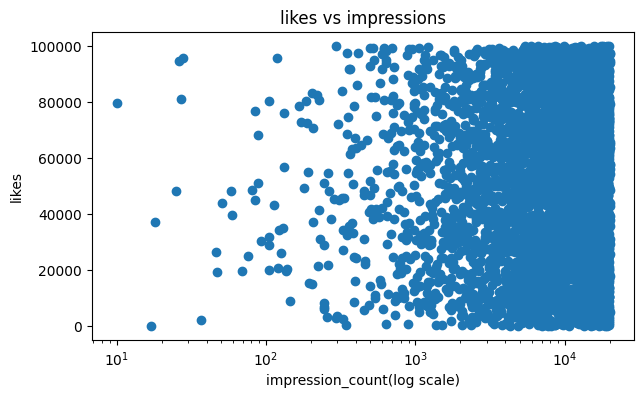

In [ ]:
#Scatter Plot:
plt.figure(figsize=(7,4))
plt.scatter(df['likes'],df['impression_count'])
plt.title('likes vs impressions')
plt.xscale('log')
plt.xlabel("impression_count(log scale)")
plt.ylabel("likes")
plt.show()

Interpretation:As impression counts increases number of likes are also increased,so there is positive correlation but smaller count values also higher likes in some points so relationship is not conssitent for all observations.

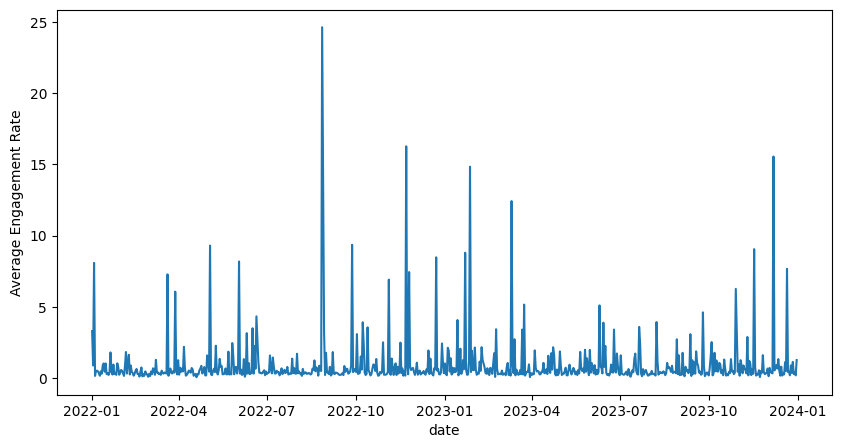

In [ ]:
#Line Plot:
df['postes at']=pd.to_datetime(df['posted_at'])
daily_engagement=df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()
plt.figure(figsize=(10,5))
plt.plot(daily_engagement.index,daily_engagement.values)
plt.xlabel('date')
plt.ylabel('Average Engagement Rate')
plt.show()

Interpretation:
 line chart shows fluctuations in engagement over time that is with some periods showing increases and others showing decreases.so it is changing across different dates.

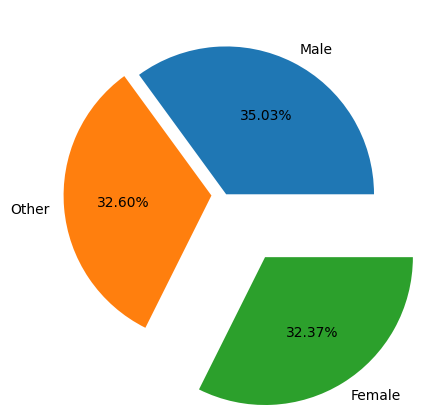

In [ ]:
#Pie:
plt.pie(df['gender'].value_counts(),labels=df['gender'].value_counts().index,autopct="%1.2f%%",explode=[0,0.1,0.5])
plt.show()

Interpretation:The pie chart shows gender distribution,male has highest number of counts among all.

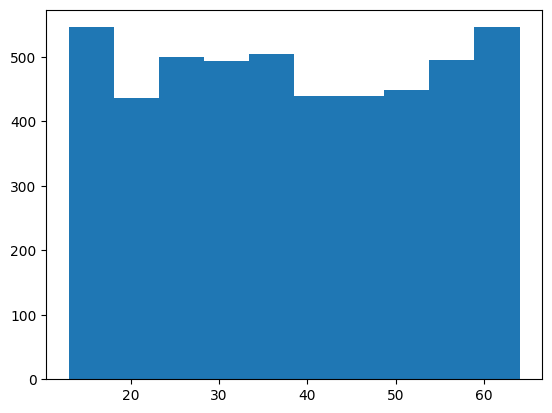

In [ ]:
#Histogram:
plt.hist(df['age'],bins=10)
plt.show()

 Interpretation:The histogram for age that is number of users for different age groups is increasing and decreasing.There is no pattern observed in the distribution.


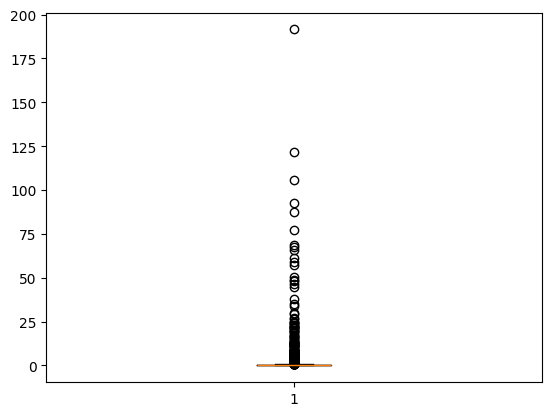

In [ ]:
#Box Plot:
plt.boxplot(df['engagement_rate'])
plt.show()

Interpretation:
In Box Plot,most of engagement rate values are concentrated near certain range but some values are out of that range which is outliers.

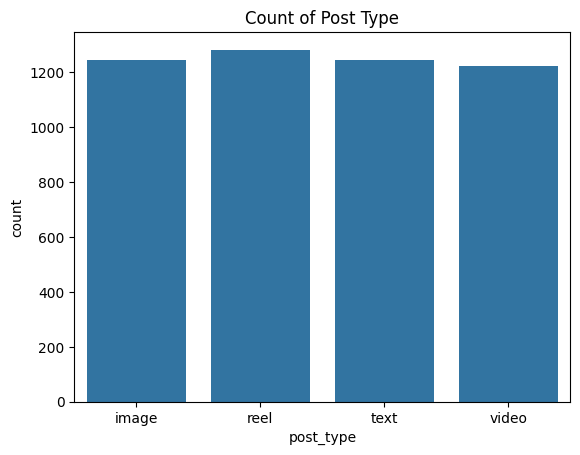

In [ ]:
#Seaborn:
#Count Plot:
sns.countplot(x='post_type',data=df)
plt.title('Count of Post Type')
plt.show()

Interpretation:Reel post type has higher reaches among all post types.

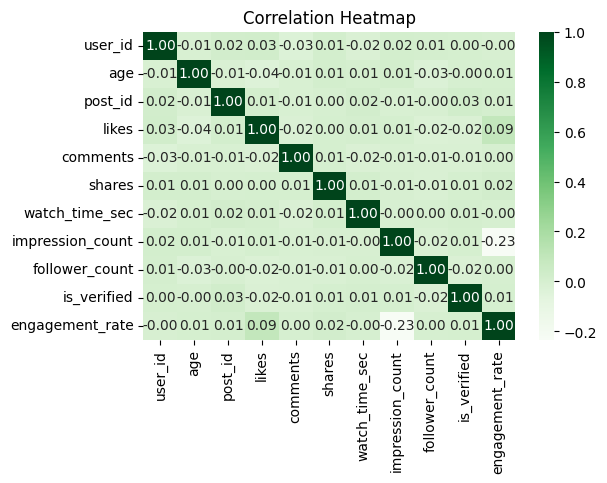

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.026228,-0.033874,0.014004,-0.016847,0.015326,0.010124,0.004058,-0.004282
age,-0.006789,1.000000,-0.013353,-0.037371,-0.007491,0.014348,0.005677,0.013513,-0.025416,-0.000112,0.008044
post_id,0.020051,-0.013353,1.000000,0.014773,-0.010724,0.001901,0.018374,-0.007709,-0.002844,0.025208,0.010139
likes,0.026228,-0.037371,0.014773,1.000000,-0.018980,0.004799,0.008837,0.008067,-0.023331,-0.016395,0.093555
comments,-0.033874,-0.007491,-0.010724,-0.018980,1.000000,0.006310,-0.016616,-0.009537,-0.011921,-0.012577,0.000046
shares,0.014004,0.014348,0.001901,0.004799,0.006310,1.000000,0.014898,-0.005178,-0.010891,0.007158,0.021804
watch_time_sec,-0.016847,0.005677,0.018374,0.008837,-0.016616,0.014898,1.000000,-0.004335,0.002761,0.012326,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.008067,-0.009537,-0.005178,-0.004335,1.000000,-0.015513,0.008317,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.023331,-0.011921,-0.010891,0.002761,-0.015513,1.000000,-0.017808,0.002292
is_verified,0.004058,-0.000112,0.025208,-0.016395,-0.012577,0.007158,0.012326,0.008317,-0.017808,1.000000,0.005528


In [ ]:
#Heatmap:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,annot=True,cmap='Greens',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
corr_matrix

Interpretation:The heatmap shows positive realtionships among numerical variables indicating that variables generally tend to increase together.

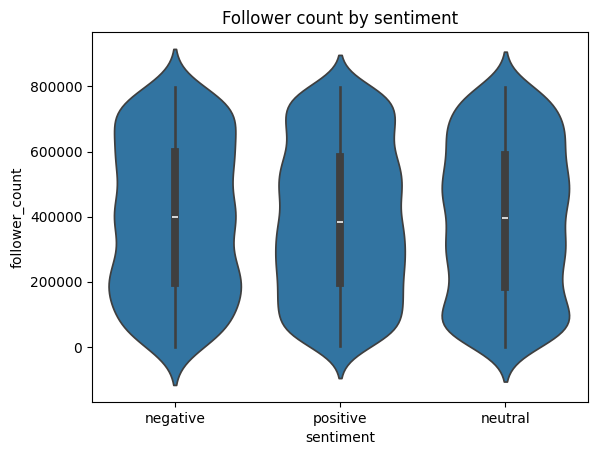

In [ ]:
#Violin Plot:
sns.violinplot(x='sentiment',y='follower_count',data=df)
plt.title('Follower count by sentiment')
plt.xlabel('sentiment')
plt.ylabel('follower_count')
plt.show()

Interpretation: In Violin plot follower count is spread overall violin and similar shapes indicates all categories have similar distributions.

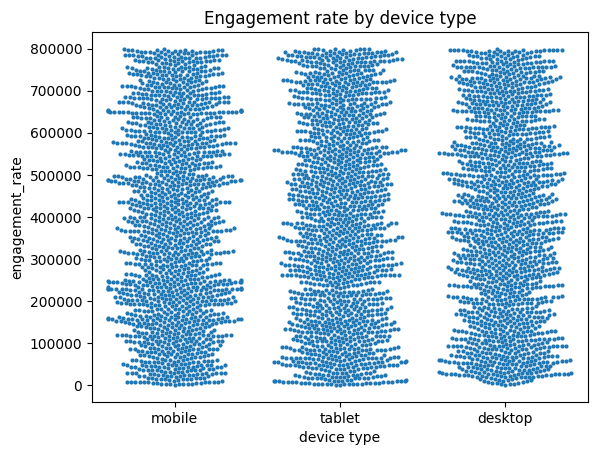

In [ ]:
#Swarm Plot:
sns.swarmplot(x='device_type',y='follower_count',data=df,size=3)
plt.title('Engagement rate by device type')
plt.xlabel('device type')
plt.ylabel('engagement_rate')
plt.show()

Interpretation:The Swarm plot shows distribution of engagement rate across different data types is almost same for all device types.

In [ ]:
#Plotly:
#Bar Chart:
import plotly.express as px
import plotly.graph_objects as go
category_count=df['post_category'].value_counts().reset_index()
category_count.columns=['category','count']
fig_bar=px.bar(category_count,x='category',y='count',title='posts by category')
fig_bar.show()

Interpretation:In plotly plot,Fitness Category has higher number of posts category compared to other categories.

<h2>Final Insights:</h2>
<h4>Content Performance:</h4>
1.Video Type has highest engagement rate.
2.Fitness category(higher)is the best performing category.
3.Brazil have highest average engagement rate.
<h4>User Trends:</h4>
1.Since correlation between age and engagement is near to 0,the relation is very weak and age has no linear relationship with engagement rate.  
2.The performance difference for verified accounts is 0.1 and verified accounts have slightly higher performance so there is small performance difference.
<h4>Behavioral Insights:</h4>
1.September month has highest
 month of impressions
2.Mobile users have highest average watch time and desktop users have lowest average watch time.
<h4>Sentiment Analysis:</h4>
1.Negative Sentiment has more likes and it performs best.
2.Negative sentiment posts have higher reach compare to neutral posts in all aspects likes,posts,shares.









